In [1]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error , mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score

In [2]:
# using linear regression 
#checking the data 
#imports 
df=pd.read_csv("diamonds.csv")
print(df.index)
print("All columns are")
ai=0
for i in df:
    print(ai,i)
    ai+=1

RangeIndex(start=0, stop=53940, step=1)
All columns are
0 carat
1 cut
2 color
3 clarity
4 depth
5 table
6 x
7 y
8 z
9 price


In [3]:
for i in df.select_dtypes(include=['object', 'string']):
    counts = df[i].value_counts()
    print(counts)

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64
color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64
clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64


In [4]:
df.select_dtypes(include='object').columns

Index(['cut', 'color', 'clarity'], dtype='object')

In [5]:
# Direct without category
X = df.drop(['price'],axis = 1)
y = df['price']
X = X.drop(columns = df.select_dtypes(include='object').columns)


Xtrain, Xtest, ytrain, ytest = train_test_split(X,y,test_size=0.2,random_state=42)


model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])


model.fit(Xtrain, ytrain)


ypred = model.predict(Xtest)


print("Accuracy Score:", r2_score(ytest, ypred))



Accuracy Score: 0.8589542625888938


In [6]:
scores = cross_val_score(model,X,y,cv=10,scoring="r2")
print("Accuracy:", scores)
print("Mean accuracy:", scores.mean())

Accuracy: [-0.58583784 -0.30722495  0.09730403  0.27685665  0.31198469  0.89911847
 -7.23937146 -3.66118427 -0.85735079 -1.31314618]
Mean accuracy: -1.2378851648924292


Index(['carat', 'depth', 'table', 'x', 'y', 'z', 'price'], dtype='object')


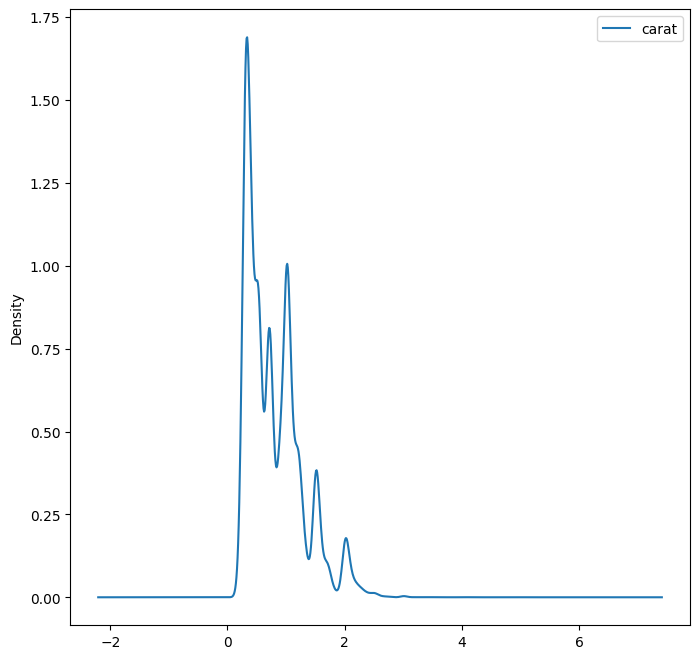

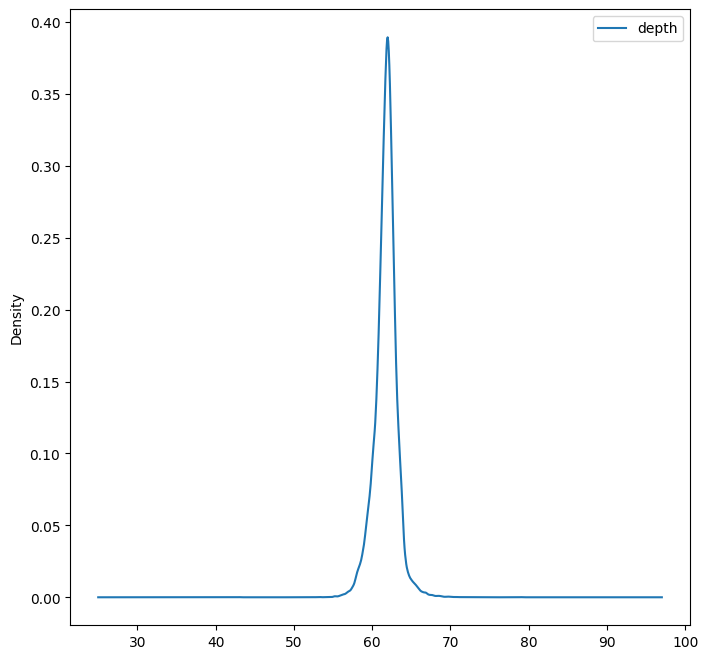

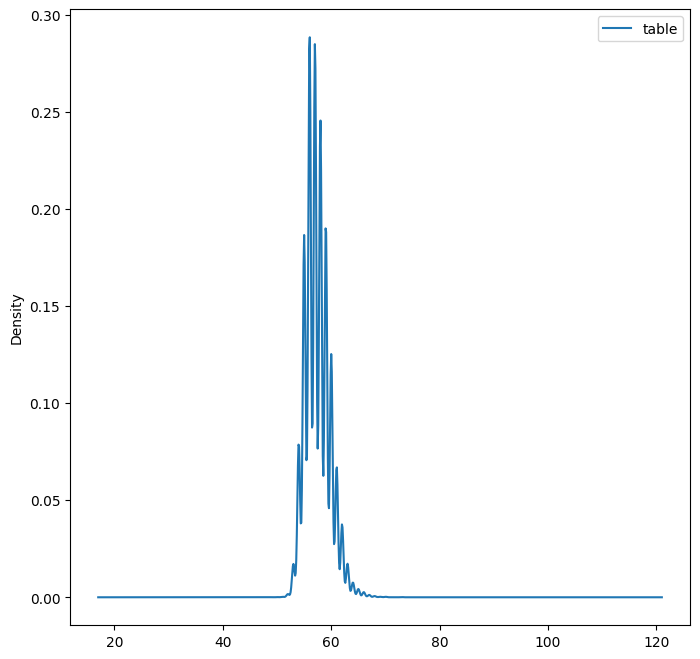

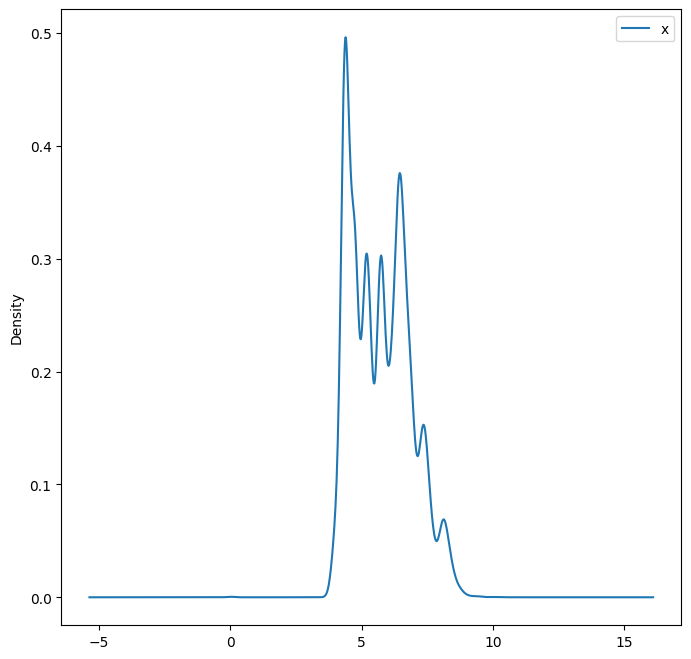

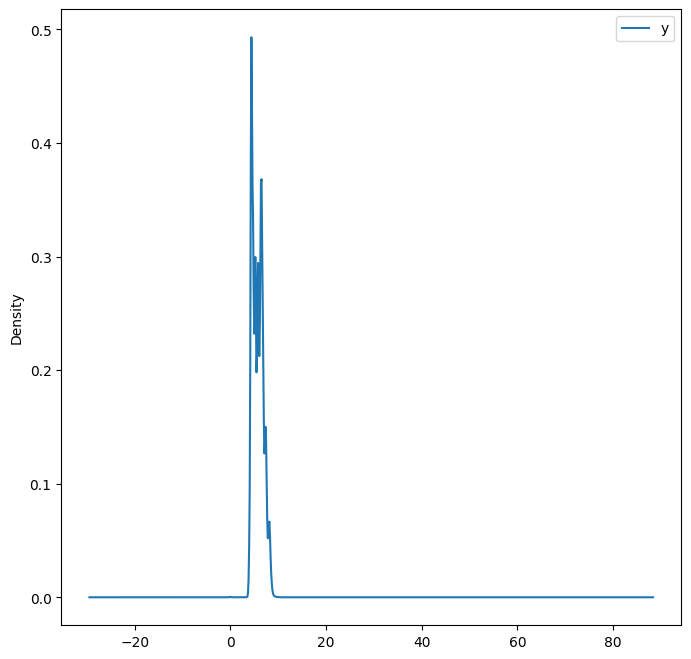

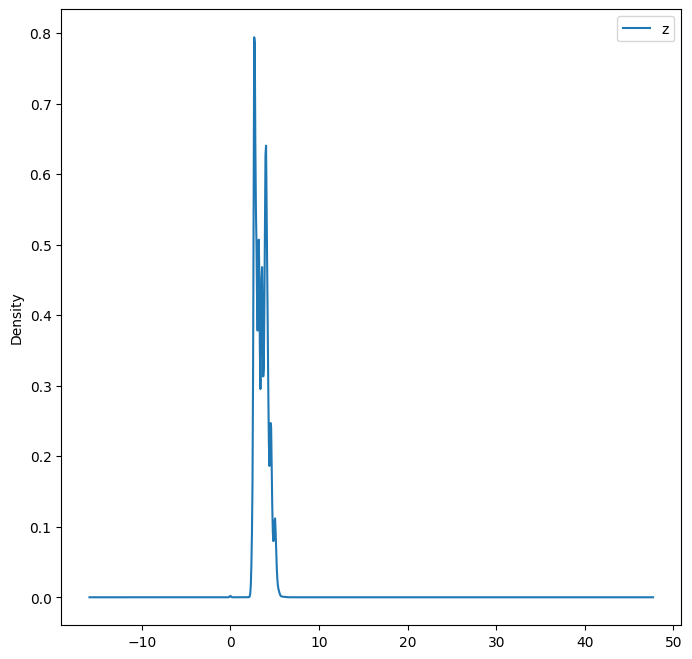

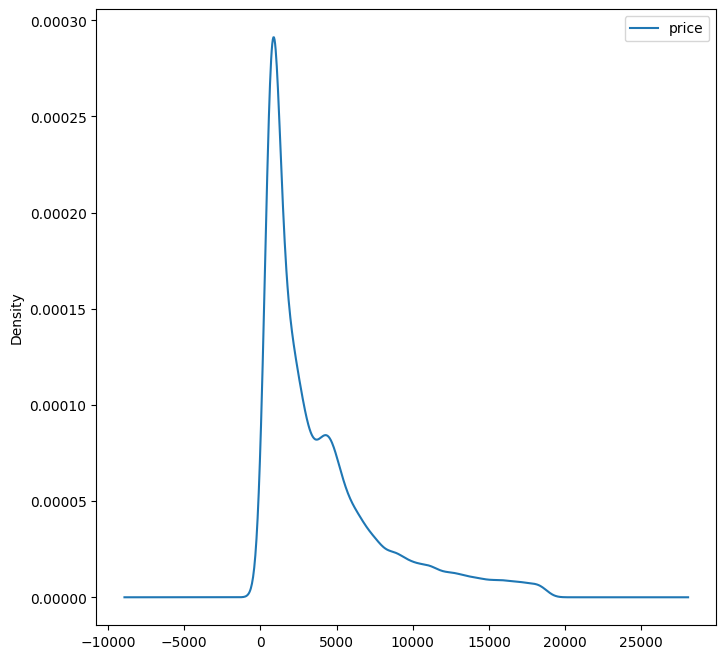

In [7]:
# custom function for printing all numeric columns plot
def plotkde(a):
    df.plot(y=[a], kind='kde',figsize=(8,8))
allnc = df.select_dtypes(include='number').columns
print(allnc)
for i in allnc:
    plotkde(i)

In [8]:
df.select_dtypes(include='object').columns

Index(['cut', 'color', 'clarity'], dtype='object')

[[-1.70684588 -0.18047936 -1.17338126 ... -1.74571843 -1.7224555
  -2.07842536]
 [-1.8159425  -1.35592485  1.50718214 ... -1.91876461 -1.94388598
  -2.07842536]
 [-1.70684588 -3.31824722  2.66532843 ... -1.63704415 -1.94388598
  -2.07497401]
 ...
 [ 0.0462695   0.730745    1.15239049 ...  0.03434562  0.09483237
   0.16679932]
 [ 0.420192   -0.5281072   0.34416705 ...  0.42044969  0.34843245
   0.16679932]
 [ 0.17139436  0.3088568  -1.17338126 ...  0.20412537  0.20856066
   0.16679932]]


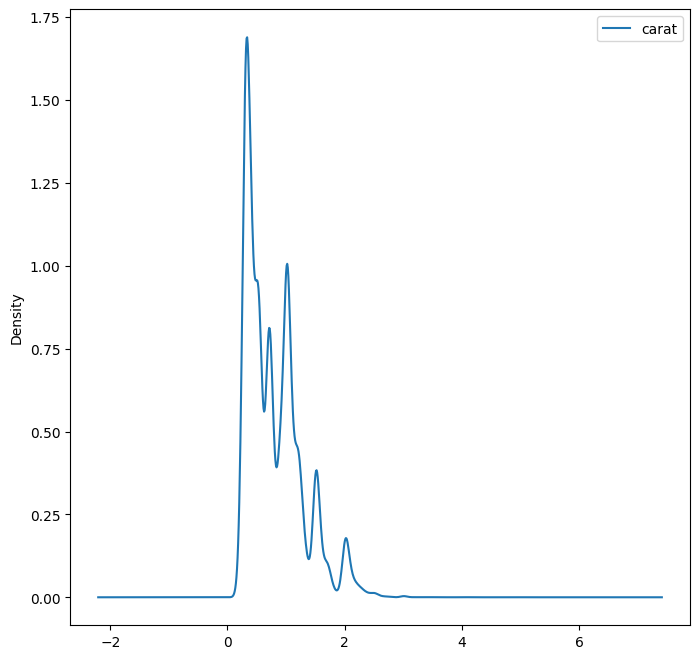

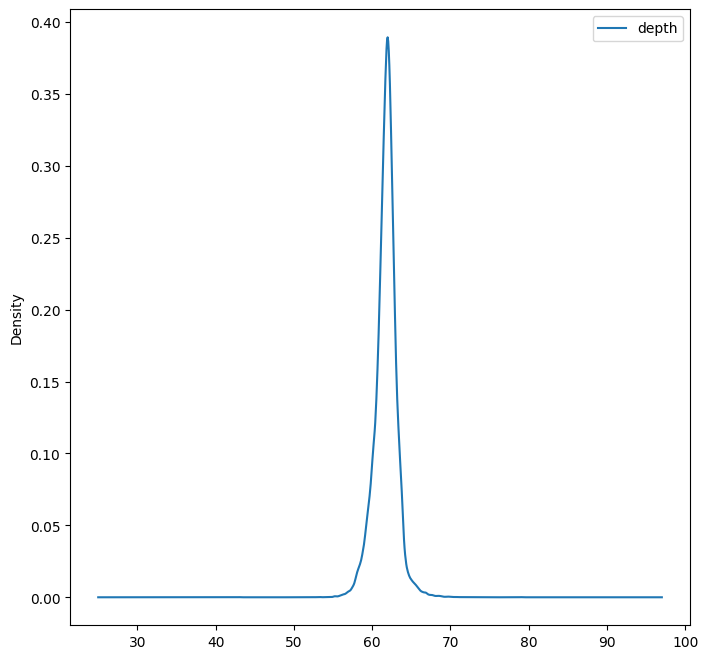

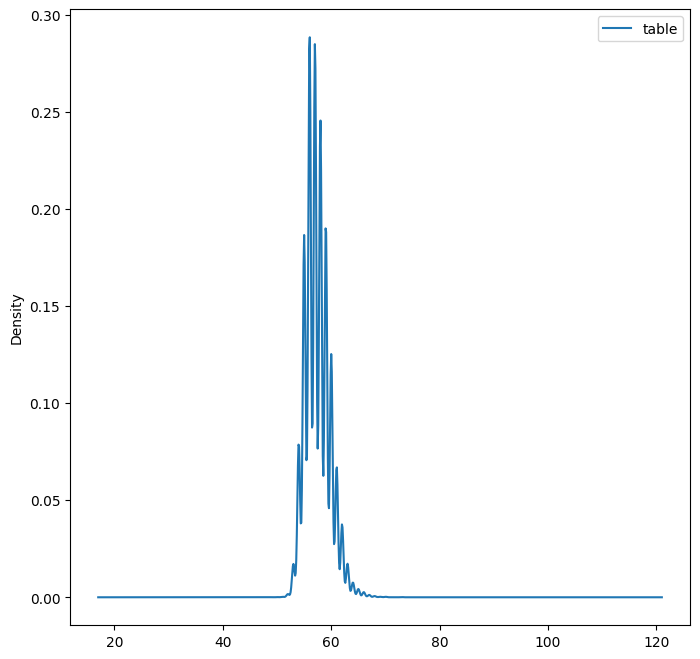

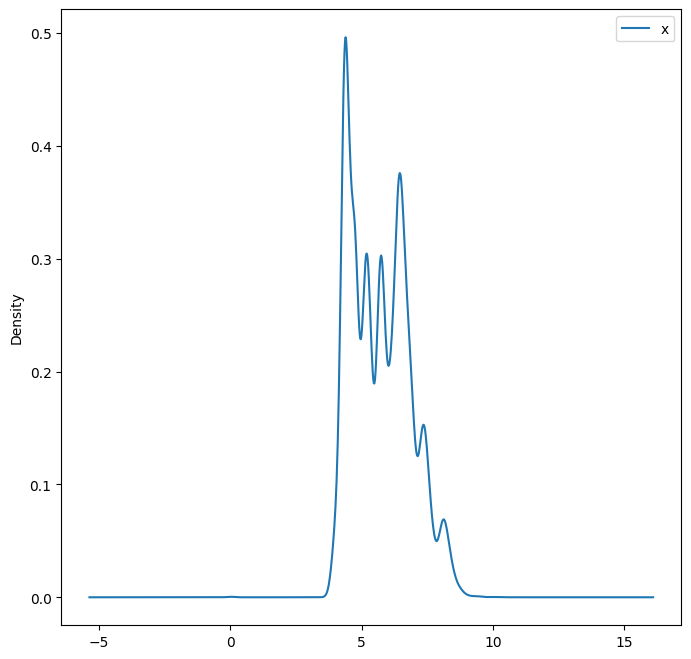

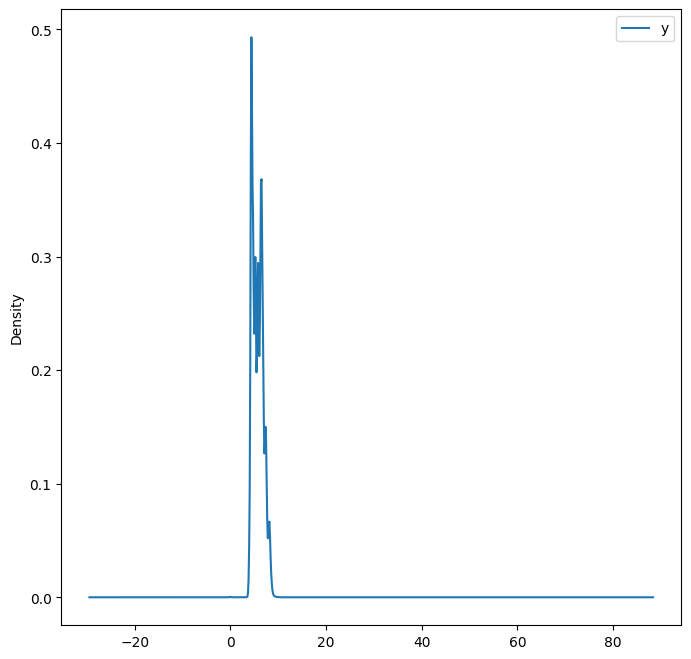

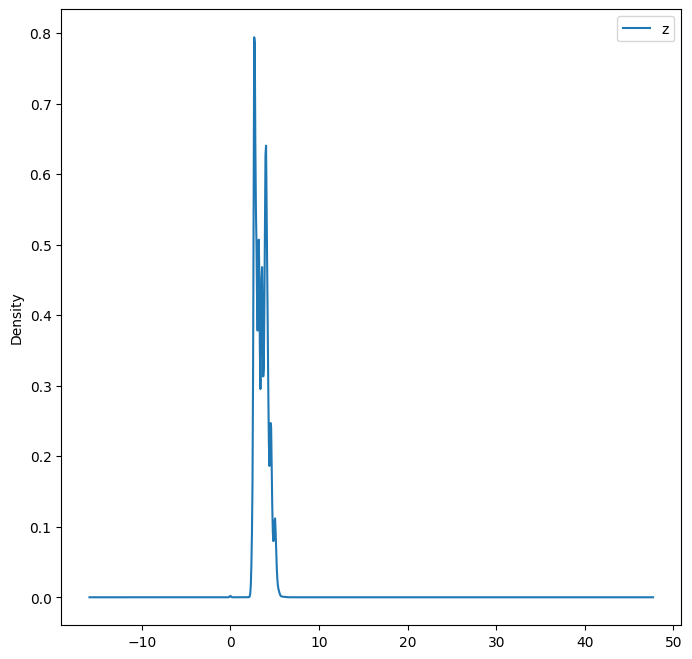

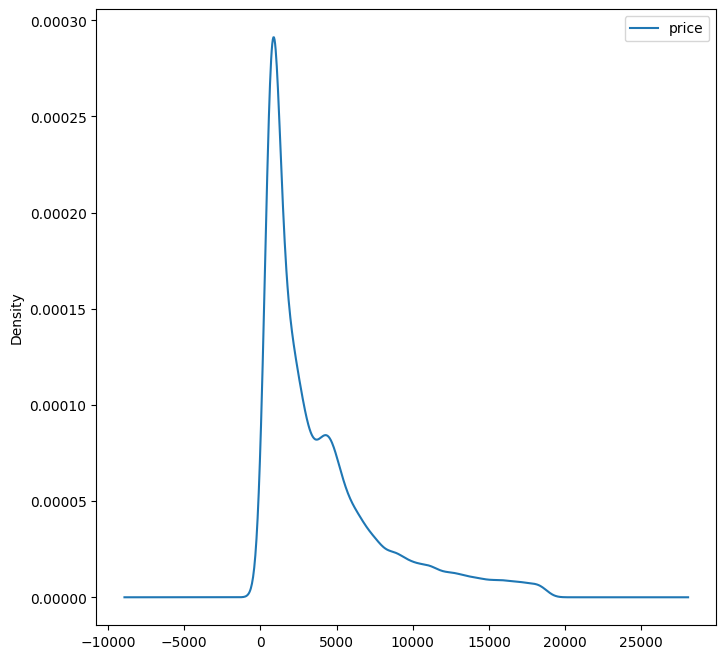

In [9]:
# after yeo-johnson

adf = df.drop(columns = df.select_dtypes(include='object').columns)

tdf = adf

pt = PowerTransformer(method='yeo-johnson', standardize=True)
transformed = pt.fit_transform(tdf)

print(transformed)

transformed= pd.DataFrame(transformed, columns = adf.columns)
for i in transformed:
    plotkde(i)

In [10]:

for col in tdf.columns:
    try:
        pt = PowerTransformer(method='yeo-johnson')
        pt.fit_transform(tdf[[col]])
        print(f"{col}: OK")
    except Exception as e:
        print(f"{col}: ERROR -> {e}")

carat: OK
depth: OK
table: OK
x: OK
y: OK
z: OK
price: OK


In [11]:
df.select_dtypes(include='number').columns

Index(['carat', 'depth', 'table', 'x', 'y', 'z', 'price'], dtype='object')

In [12]:
# Yeo-Johnson completed its work and 
# now all the numerical columns are scaled and has their best possible lamda values
print('\n',pt.lambdas_)


 [-0.0674]


In [13]:
print(tdf.columns)

Index(['carat', 'depth', 'table', 'x', 'y', 'z', 'price'], dtype='object')


In [16]:

X = df.drop(
    columns=[
        "price"
    ],
    errors='ignore'
)

y = df['price']


numeric_cols = X.select_dtypes(include='number').columns
categorical_cols = X.select_dtypes(include='object').columns


preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])


pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', LinearRegression())
])


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


pipe.fit(X_train, y_train)



Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['carat', 'depth', 'table', 'x', 'y', 'z'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['cut', 'color', 'clarity'], dtype='object'))])),
                ('model', LinearRegression())])

In [17]:

print("Train R²:", pipe.score(X_train, y_train))
print("Test R²:", pipe.score(X_test, y_test))

# Cross-validation
cv_scores = cross_val_score(
    pipe,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("\nCV R² Scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())

Train R²: 0.919994314909212
Test R²: 0.9189331350419387

CV R² Scores: [  0.34224026   0.70010775   0.83186637 -14.25049522  -0.86365774]
Mean CV R²: -2.6479877163177177
